In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
#!pip install -r ../requirements.txt

sklearn - > scikilearn\
train_test_spli -> amostragem. dividir o dataset entre conjunto de treino e teste.

In [3]:
iris = pd.read_csv("../data/flores_iris.csv")
iris = iris.sample(frac=1) # Embaralhando o dataset
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
30,31,4.8,3.1,1.6,0.2,Iris-setosa
45,46,4.8,3.0,1.4,0.3,Iris-setosa
14,15,5.8,4.0,1.2,0.2,Iris-setosa
26,27,5.0,3.4,1.6,0.4,Iris-setosa
117,118,7.7,3.8,6.7,2.2,Iris-virginica
...,...,...,...,...,...,...
137,138,6.4,3.1,5.5,1.8,Iris-virginica
91,92,6.1,3.0,4.6,1.4,Iris-versicolor
132,133,6.4,2.8,5.6,2.2,Iris-virginica
95,96,5.7,3.0,4.2,1.2,Iris-versicolor


In [4]:
'''
Antes de iniciar, vamos separar uma amostra de 10 dados para teste.
Esses dados não deveme estar no conjunto de treinamento.
Queremos que o modelo treinado saiba classificar dados que ele nunca viu.
'''
iris_teste = iris.sample(n=10)

In [5]:
iris_teste

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
3,4,4.6,3.1,1.5,0.2,Iris-setosa
124,125,6.7,3.3,5.7,2.1,Iris-virginica
78,79,6.0,2.9,4.5,1.5,Iris-versicolor
24,25,4.8,3.4,1.9,0.2,Iris-setosa
46,47,5.1,3.8,1.6,0.2,Iris-setosa
103,104,6.3,2.9,5.6,1.8,Iris-virginica
126,127,6.2,2.8,4.8,1.8,Iris-virginica
134,135,6.1,2.6,5.6,1.4,Iris-virginica
71,72,6.1,2.8,4.0,1.3,Iris-versicolor


In [6]:
iris["Id"].isin(iris_teste['Id'])

30     False
45     False
14     False
26     False
117    False
       ...  
137    False
91     False
132    False
95     False
2      False
Name: Id, Length: 150, dtype: bool

In [7]:
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
30,31,4.8,3.1,1.6,0.2,Iris-setosa
45,46,4.8,3.0,1.4,0.3,Iris-setosa
14,15,5.8,4.0,1.2,0.2,Iris-setosa
26,27,5.0,3.4,1.6,0.4,Iris-setosa
117,118,7.7,3.8,6.7,2.2,Iris-virginica
...,...,...,...,...,...,...
137,138,6.4,3.1,5.5,1.8,Iris-virginica
91,92,6.1,3.0,4.6,1.4,Iris-versicolor
132,133,6.4,2.8,5.6,2.2,Iris-virginica
95,96,5.7,3.0,4.2,1.2,Iris-versicolor


In [8]:
'''
Dataset de treinamento agora com N - 10 dados
'''
iris.shape

(150, 6)

In [9]:
iris.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [10]:
'''
Separando X (features) e y (classes)
'''

X = iris.drop(['Species', 'Id'], axis=1)
y = iris['Species']

In [11]:
y

30         Iris-setosa
45         Iris-setosa
14         Iris-setosa
26         Iris-setosa
117     Iris-virginica
            ...       
137     Iris-virginica
91     Iris-versicolor
132     Iris-virginica
95     Iris-versicolor
2          Iris-setosa
Name: Species, Length: 150, dtype: object

In [12]:
y.value_counts()

Species
Iris-setosa        50
Iris-virginica     50
Iris-versicolor    50
Name: count, dtype: int64

In [13]:
'''
Faremos uma classificação binária: 1 é Iris-setosa e 0 não
'''

y = y.map(
    {'Iris-setosa': 0,
     'Iris-versicolor': 1,
     'Iris-virginica': 0
     })

In [14]:
y

30     0
45     0
14     0
26     0
117    0
      ..
137    0
91     1
132    0
95     1
2      0
Name: Species, Length: 150, dtype: int64

In [15]:
'''
Mesma transformação feita para o conjunto de teste.
'''

iris_teste['Species'] = iris_teste['Species'].map(
    {'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 0}
)

- Treinamento: Conjunto onde o modelo vai aprender as características e ajustar os seus parâmetros
- Validação: Valida o treinamento. Verifica se o erro está diminuindo

In [16]:
'''
Divisão entre conjunto de treinamento e validação
'''

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
134,6.1,2.6,5.6,1.4
138,6.0,3.0,4.8,1.8
54,6.5,2.8,4.6,1.5
19,5.1,3.8,1.5,0.3
82,5.8,2.7,3.9,1.2
...,...,...,...,...
144,6.7,3.3,5.7,2.5
100,6.3,3.3,6.0,2.5
8,4.4,2.9,1.4,0.2
36,5.5,3.5,1.3,0.2


In [18]:
y_train.value_counts()

Species
0    79
1    41
Name: count, dtype: int64

In [19]:
'''
Padronizando os dados
z = (x - media) / desvio_padrao
Especialmente útil no gradiente descendente, onde a escala dos dados pode afetar a convergência
Padronizando os dados para que tenham média 0 e desvio padrão 1

Isso é feito após a divisão treino teste
Data leakage: Se feito antes, calculamos estatísticas do conjunto
de treino que podem "vazar" para o conjunto de teste.
'''

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [20]:
'''
Criamos uma instância do modelo classificador.
Nesse caso é a regressão logística.
Chamamos a função "fit()", que realiza o treinamento do modelo em nosso conjunto de dados.
Perceba que as features X são passadas separadamente das labels y.
'''
model = LogisticRegression(solver="sag") # "sag" é o gradiente descendente
model.fit(X_train, y_train)

LogisticRegression(solver='sag')

In [21]:
X_val

array([[ 0.64141589,  0.33860633,  0.39282952,  0.37523789],
       [-1.5369777 ,  1.35442531, -1.60219343, -1.34139293],
       [ 0.76243776, -0.16930316,  0.96283608,  0.77138346],
       [-0.32675904, -0.9311674 ,  0.22182755,  0.11114084],
       [ 1.36754709,  0.33860633,  0.50683083,  0.24318937],
       [-0.20573717,  3.38606329, -1.31719015, -1.07729588],
       [-0.93186837,  0.84651582, -1.31719015, -1.34139293],
       [-0.4477809 , -1.94698639,  0.10782624,  0.11114084],
       [ 1.24652522,  0.33860633,  1.07683739,  1.43162608],
       [ 0.15732843, -2.20094114,  0.6778328 ,  0.37523789],
       [-1.65799956, -1.94698639, -1.43119146, -1.2093444 ],
       [-1.1739121 ,  0.08465158, -1.31719015, -1.47344145],
       [ 1.00448149, -0.16930316,  0.79183411,  1.43162608],
       [-1.41595583,  0.33860633, -1.2601895 , -1.34139293],
       [-1.05289023, -2.70885063, -0.17717704, -0.28500473],
       [-0.32675904, -1.4390769 ,  0.05082558, -0.15295621],
       [-0.93186837,  1.

In [22]:
'''
Uma vez treinado, podemos usar os dados de validação do treinamento
para ver a "qualidade" das respostas do modelo.

A função "predict()" realiza a predição das classes. Perceba
que passamos apenas o conjunto X_val, sem as labels. O modelo
irá retornar um array com as suas predições para cada linha.
'''

model.predict(X_val)

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0])

In [23]:
'''
Como possuímos o conjunto y_val que contém os valores reais
do conjunto de validação, podemos comparar ambos.
'''

preditos = model.predict(X_val)

In [24]:
y_val

51     1
22     0
116    0
94     1
50     1
15     0
39     0
53     1
120    0
119    0
41     0
34     0
145    0
29     0
60     1
69     1
17     0
104    0
123    0
109    0
33     0
68     1
80     1
58     1
146    0
137    0
13     0
40     0
149    0
47     0
Name: Species, dtype: int64

In [25]:
preditos

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0])

In [26]:
'''
No classification report: Precisão -> TP/(TP+FP), Sensibilidade -> Recall TP/(TP+FN)
'''
print(classification_report(y_val, preditos))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83        21
           1       0.60      0.67      0.63         9

    accuracy                           0.77        30
   macro avg       0.72      0.74      0.73        30
weighted avg       0.77      0.77      0.77        30



In [27]:
'''
Matriz de confusão
'''
cm = confusion_matrix(y_val, preditos)
cm

array([[17,  4],
       [ 3,  6]])

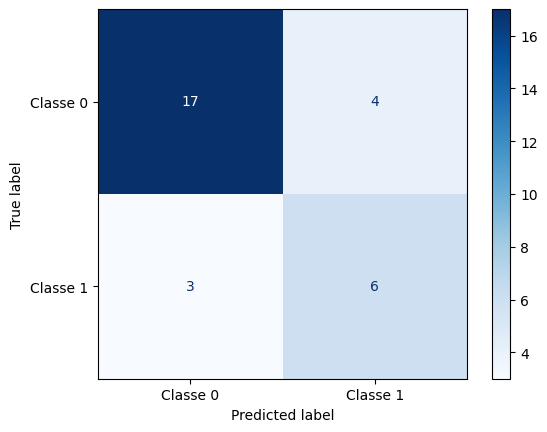

In [28]:
# ConfusionMatrixDisplay permite plotar com rótulos e cores
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues')
plt.show()

### Teste

In [29]:
iris_teste

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
53,54,5.5,2.3,4.0,1.3,1
3,4,4.6,3.1,1.5,0.2,0
124,125,6.7,3.3,5.7,2.1,0
78,79,6.0,2.9,4.5,1.5,1
24,25,4.8,3.4,1.9,0.2,0
46,47,5.1,3.8,1.6,0.2,0
103,104,6.3,2.9,5.6,1.8,0
126,127,6.2,2.8,4.8,1.8,0
134,135,6.1,2.6,5.6,1.4,0
71,72,6.1,2.8,4.0,1.3,1


In [33]:
!pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: No matching distribution found for pickle


In [30]:
real_test = iris_teste['Species']
iris_teste = iris_teste.drop(["Species", "Id"], axis=1)
iris_teste = scaler.fit_transform(iris_teste)
pred_test = model.predict(iris_teste)

compara = pd.DataFrame({"Predito": pred_test, "Real": real_test})

In [35]:
import pickle

# Save the model
with open('modelo_regressao_iris.pkl', 'wb') as f:
    pickle.dump(model, f)

In [36]:
# Load the model
with open('modelo_regressao_iris.pkl', 'rb') as f:
    modelo_carregado = pickle.load(f)

In [38]:
modelo_carregado.predict(iris_teste)

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0])

### Experimento

Teste o modelo para predizer as outras duas espécies.
Por que os valores como predição e acurácia são diferentes?